# Pointing Cut Example

This example reads a DC4 unbinned AGN FITS file, builds good time intervals for a source using the default COSI field-of-view cut, and writes a binned `.hdf5` file containing events either inside or outside that FOV selection.

The FOV selection uses `GoodTimeInterval.from_pointing_cut`, with the default example value `max_offaxis = 60 * u.deg`, to keep events when the source is inside the FOV.

**Note:** The data, background, and orientation files should all be time cut using the same conditions to get the best results.

In [1]:
from pathlib import Path
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from histpy import Histogram

from cosipy import BinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.spacecraftfile import SpacecraftHistory

%matplotlib inline

11:24:37 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=395802;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=910416;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=691325;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=519661;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=138486;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=112404;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

11:24:38 INFO      Starting 3ML!                                                                     ]8;id=210314;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=683408;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=260821;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=238509;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

11:24:39 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=424292;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=933848;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=918658;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=872498;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=7532;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=300039;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=865867;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=95213;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=696937;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=45407;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

Update these paths for the source you want to analyze

In [ ]:
### Background file to apply pointing cuts
bkg_file = Path(
    "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits"
)

## Data file to apply pointing cuts
data_file = Path(
    "dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered.fits"
)

orientation_file = Path(
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)

### This config is only used to initialize the DataIO object. The data and orientation paths are set explicitly above for this example.
config_file = Path("inputs.yaml")

Change details below for the source to be analyzed

In [3]:
source_name = "NGC 4151"
source_coord = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")

### Default FOV cut used by the pointing-cut helper.
max_offaxis = 60 * u.deg
earth_occ = True

Read the unbinned FITS data and open the spacecraft orientation over the event time range.

In [4]:
analysis = BinnedData(str(config_file))
analysis.data_file = str(data_file)
analysis.ori_file = str(orientation_file)
analysis.unbinned_output = "fits"

analysis.cosi_dataset = analysis.get_dict(str(data_file))
time_tags = analysis.cosi_dataset["TimeTags"]

event_tstart = Time(np.min(time_tags), format="unix", scale="utc")
event_tstop = Time(np.max(time_tags), format="unix", scale="utc")

sc_history = SpacecraftHistory.open(
    orientation_file,
    tstart=event_tstart,
    tstop=event_tstop,
).select_interval(event_tstart, event_tstop)

print(f"Input events: {len(time_tags):,}")
print(f"Event time range: {event_tstart.isot} to {event_tstop.isot}")
print(f"Orientation pointings: {len(sc_history.obstime):,}")

Input events: 182,327,971
Event time range: 2028-03-01T01:35:00.036 to 2028-06-01T10:14:14.888
Orientation pointings: 531,998


Cut the orientation file to the selected event time range. The cut orientation can be written to disk for later analysis, or the in-memory `time_cut_orientation` object can be passed directly to code that needs the selected spacecraft history.


In [5]:
time_cut_orientation = SpacecraftHistory.open(
    orientation_file,
    tstart=event_tstart,
    tstop=event_tstop,
).select_interval(event_tstart, event_tstop)

print(f"Time-cut orientation pointings: {len(time_cut_orientation.obstime):,}")


Time-cut orientation pointings: 531,998


Build the GTIs where the source is inside the FOV.

In [6]:
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    time_cut_orientation,
    max_offaxis,
    earth_occ=earth_occ,
)

pointing_cut_orientation = time_cut_orientation.apply_gti(source_gti)
gti_livetime = pointing_cut_orientation.cumulative_livetime().to_value(u.s)
total_livetime = time_cut_orientation.cumulative_livetime().to_value(u.s)
livetime_fraction = gti_livetime / total_livetime

print(f"Source: {source_name}")
print(f"FOV cut: off-axis <= {max_offaxis.to_value(u.deg):.1f} deg")
print(f"GTI intervals: {len(source_gti)}")
print(f"GTI livetime: {gti_livetime:,.1f} s")
print(f"Total livetime: {total_livetime:,.1f} s")
print(f"Livetime fraction in FOV: {livetime_fraction:.4f}")


Source: NGC 4151
FOV cut: off-axis <= 60.0 deg
GTI intervals: 675
GTI livetime: 980,415.0 s
Total livetime: 6,579,555.0 s
Livetime fraction in FOV: 0.1490


Inspect the source off-axis angle. The horizontal line is the FOV threshold used to build the GTIs.

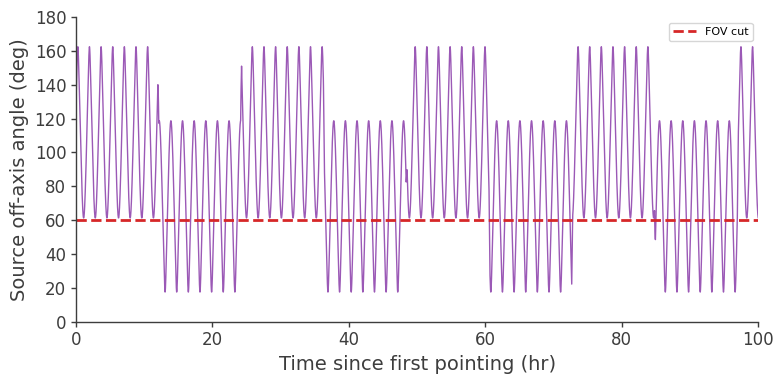

In [7]:
source_sc = time_cut_orientation.get_target_in_sc_frame(source_coord)
offaxis = (np.pi / 2 * u.rad - source_sc.lat).to_value(u.deg)
time_hours = (time_cut_orientation.obstime.unix - time_cut_orientation.obstime.unix[0]) / 3600

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_hours, offaxis, lw=1)
ax.axhline(max_offaxis.to_value(u.deg), color="tab:red", ls="--", label="FOV cut")
ax.set_xlabel("Time since first pointing (hr)")
ax.set_ylabel("Source off-axis angle (deg)")
ax.set_ylim(0, 180)
ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()


Apply the GTI to the mock-data file. This uses the same half-open convention as `select_data_time`: events are kept for `start <= TimeTags < stop`.


In [8]:
in_fov_mask = source_gti.contains(analysis.cosi_dataset["TimeTags"])
n_in_fov = np.count_nonzero(in_fov_mask)
n_out_fov = len(in_fov_mask) - n_in_fov

analysis.cosi_dataset = {
    key: values[in_fov_mask]
    for key, values in analysis.cosi_dataset.items()
}
selected_time_tags = analysis.cosi_dataset["TimeTags"]
analysis.tmin = float(np.min(selected_time_tags))
analysis.tmax = float(np.max(selected_time_tags))

print(f"Events in FOV: {n_in_fov:,}")
print(f"Events outside FOV: {n_out_fov:,}")


Events in FOV: 26,164,190
Events outside FOV: 156,163,781


Apply the same pointing-cut time intervals to the background file, following the same unbinned-selection and binning pattern used in the other tutorial notebooks.


In [9]:
background = BinnedData(str(config_file))
background.data_file = str(bkg_file)
background.unbinned_output = "fits"

background.cosi_dataset = background.get_dict(str(bkg_file))
bkg_in_fov_mask = source_gti.contains(background.cosi_dataset["TimeTags"])

background.cosi_dataset = {
    key: values[bkg_in_fov_mask]
    for key, values in background.cosi_dataset.items()
}
selected_bkg_time_tags = background.cosi_dataset["TimeTags"]
background.tmin = float(np.min(selected_bkg_time_tags))
background.tmax = float(np.max(selected_bkg_time_tags))

background.get_binned_data(
    make_binning_plots=False,
    show_plots=False,
)

print(f"Background events in FOV: {np.count_nonzero(bkg_in_fov_mask):,}")
print(f"Background events outside FOV: {len(bkg_in_fov_mask) - np.count_nonzero(bkg_in_fov_mask):,}")


fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


Background events in FOV: 25,071,036
Background events outside FOV: 143,577,508


In [10]:
analysis.get_binned_data(
    make_binning_plots=False,
    show_plots=False,
)

Compare the FOV-selected binned mock-data and background histograms to the full binned mock-data and background histograms.


Full mock-data binned counts: 182,327,970
FOV-selected mock-data binned counts: 26,164,189
Mock-data selected fraction: 0.1435
Full background binned counts: 168,648,544
FOV-selected background binned counts: 25,071,034
Background selected fraction: 0.1487
Background/data count ratio: 0.9582


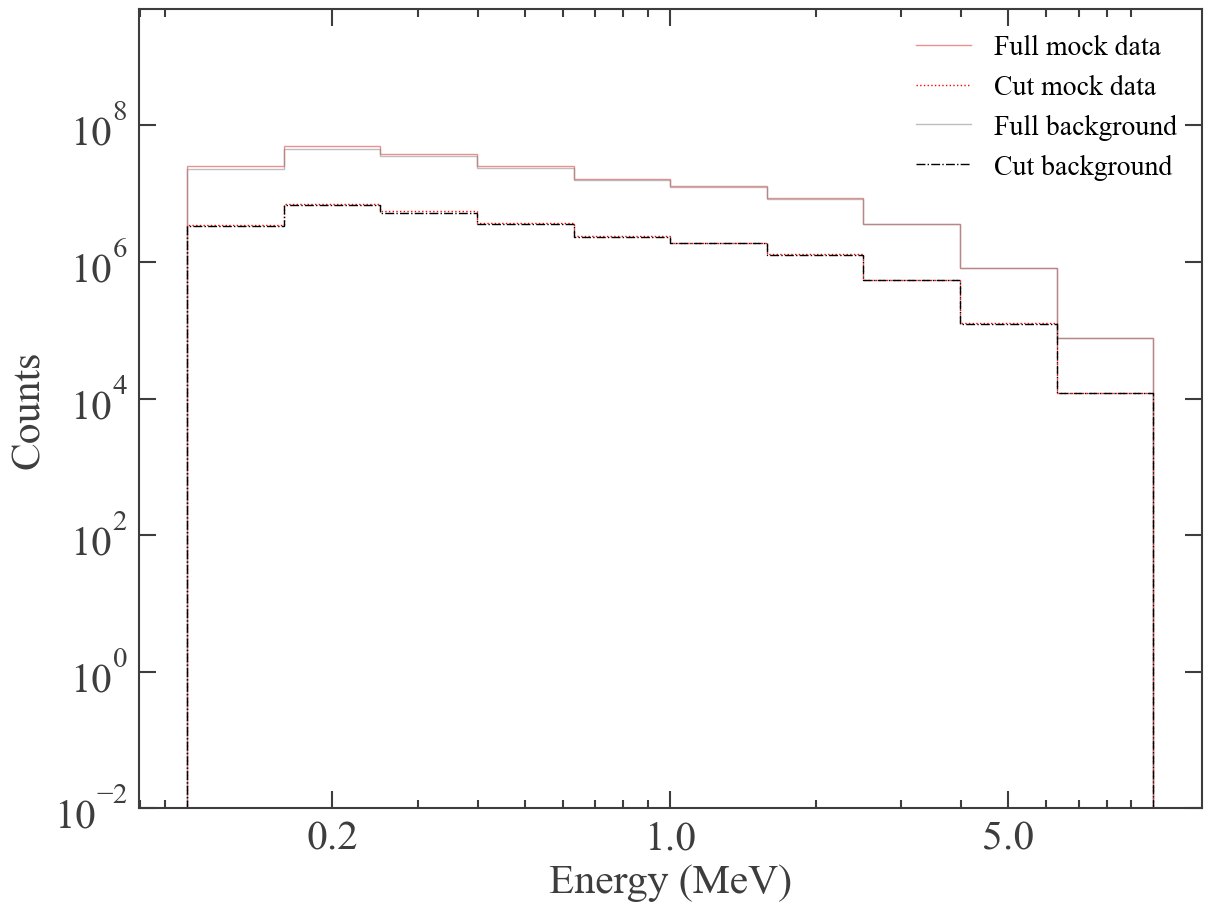

In [ ]:
full_binned_data_file = Path(
    "dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5"
)
full_binned_bkg_file = Path(
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
)

FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

time_cut_hist = analysis.binned_data
time_cut_bkg_hist = background.binned_data
full_hist = Histogram.open(full_binned_data_file)
full_bkg_hist = Histogram.open(full_binned_bkg_file)


def projection_counts(hist, axis_name):
    return hist.project(axis_name).to_dense(copy=False).contents


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


time_cut_counts = projection_counts(time_cut_hist, "Time")
time_cut_bkg_counts = projection_counts(time_cut_bkg_hist, "Time")
full_counts = projection_counts(full_hist, "Time")
full_bkg_counts = projection_counts(full_bkg_hist, "Time")

time_cut_energy_counts = projection_counts(time_cut_hist, "Em")
time_cut_bkg_energy_counts = projection_counts(time_cut_bkg_hist, "Em")
full_energy_counts = projection_counts(full_hist, "Em")
full_bkg_energy_counts = projection_counts(full_bkg_hist, "Em")
time_cut_energy_edges = time_cut_hist.axes["Em"].edges.to_value(u.keV)
time_cut_bkg_energy_edges = time_cut_bkg_hist.axes["Em"].edges.to_value(u.keV)
full_energy_edges = full_hist.axes["Em"].edges.to_value(u.keV)
full_bkg_energy_edges = full_bkg_hist.axes["Em"].edges.to_value(u.keV)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)
ax.stairs(full_energy_counts, full_energy_edges / 1000, label="Full mock data", color="tab:red", linestyle="solid", alpha=0.5)
ax.stairs(time_cut_energy_counts, time_cut_energy_edges / 1000, label=f"Cut mock data", color="red", linestyle="dotted")
ax.stairs(full_bkg_energy_counts, full_bkg_energy_edges / 1000, label="Full background", color="tab:gray", linestyle="solid", alpha=0.5)
ax.stairs(time_cut_bkg_energy_counts, time_cut_bkg_energy_edges / 1000, label=f"Cut background", color="black", linestyle="dashdot")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc="upper right", frameon=False)

print(f"Full mock-data binned counts: {np.sum(full_counts):,.0f}")
print(f"FOV-selected mock-data binned counts: {np.sum(time_cut_counts):,.0f}")
print(f"Mock-data selected fraction: {np.sum(time_cut_counts) / np.sum(full_counts):.4f}")
print(f"Full background binned counts: {np.sum(full_bkg_counts):,.0f}")
print(f"FOV-selected background binned counts: {np.sum(time_cut_bkg_counts):,.0f}")
print(f"Background selected fraction: {np.sum(time_cut_bkg_counts) / np.sum(full_bkg_counts):.4f}")
print(f"Background/data count ratio: {np.sum(time_cut_bkg_counts) / np.sum(time_cut_counts):.4f}")


Save the plotted, FOV-selected data and background files.


In [ ]:
### Fill in these output names to save the files after the pointing cut.
binned_output_prefix = "dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered"
binned_bkg_output_prefix = "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck"

analysis.binned_data.write(f"{binned_output_prefix}.hdf5", overwrite=True)
background.binned_data.write(f"{binned_bkg_output_prefix}.hdf5", overwrite=True)

print(f"Wrote: {binned_output_prefix}.hdf5")
print(f"Wrote: {binned_bkg_output_prefix}.hdf5")


Save the pointing cut orientation file if needed. The time cut can be performed and used on the orientation file in analysis directy as shown above.

In [ ]:
orientation_output_file = "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA_NGC4151_cut"
pointing_cut_orientation.write_fits(orientation_output_file, overwrite=True)
print(f"Wrote: {orientation_output_file}")
